In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"spam.csv", encoding='latin1')

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2010,ham,Dunno lei... I thk mum lazy to go out... I nev...,NaN,NaN,NaN
3086,ham,So i asked how's anthony. Dad. And your bf,NaN,NaN,NaN
1340,ham,Might ax well im there.,NaN,NaN,NaN
2267,ham,Finish liao... U?,NaN,NaN,NaN
555,ham,O. Well uv causes mutations. Sunscreen is like...,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.ndim

2

In [6]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

# Data Cleaning

In [7]:
# drop last 3 cols
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
df.sample(5)

,v1,v2
4267,ham,Hey so whats the plan this sat?
3506,ham,Two fundamentals of cool life: \Walk
2526,ham,Do u noe how 2 send files between 2 computers?
2569,ham,Ultimately tor motive tui achieve korli.
1254,ham,What your plan for pongal?


In [8]:
# renaming the columns
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df.sample(5)


,target,text
4932,ham,Once free call me sir.
3747,ham,"A bit of Ur smile is my hppnss, a drop of Ur t..."
5417,ham,Nope. I just forgot. Will show next week
221,ham,There is os called ubandu which will run witho...
1,ham,Ok lar... Joking wif u oni...


In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])

In [10]:
df.sample(5)

,target,text
2428,0,She.s find. I sent you an offline message to k...
1905,0,"There're some people by mu, I'm at the table b..."
2433,0,Indians r poor but India is not a poor country...
389,0,Yup having my lunch buffet now.. U eat already?
2363,1,Fantasy Football is back on your TV. Go to Sky...


In [11]:
df.head(5)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# Missing values

In [12]:
df.isnull().sum()

target    0
text      0
dtype: int64

# chack for duplicate values

In [13]:
df.duplicated().sum()

np.int64(403)

# remove duplicate

In [14]:
df = df.drop_duplicates(keep='first')

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


# 2.EDA

In [17]:
df["target"].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

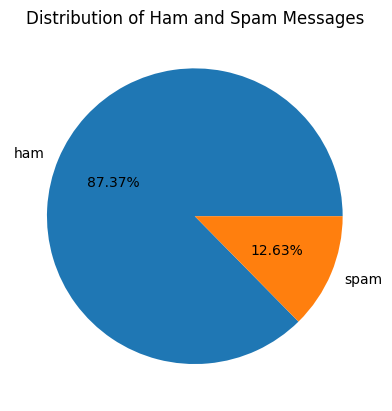

In [18]:
plt.pie(df["target"].value_counts(), labels=['ham', 'spam'], autopct='%1.2f%%')
plt.title('Distribution of Ham and Spam Messages')
plt.show()

#data is imbalanced

In [19]:
import nltk
nltk.download('punkt')
#nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [20]:
df['num_characters'] = df['text'].apply(len)

In [21]:
df.head(5)

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [22]:
# num of words
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [23]:
df.head(2)

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8


In [24]:
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [25]:
df.head(2)

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2


In [26]:
df[['num_words', 'num_sentences', 'num_characters']].describe()

,num_words,num_sentences,num_characters
count,5169.000000,5169.000000,5169.000000
mean,18.455794,1.965564,78.977945
std,13.324758,1.448541,58.236293
min,1.000000,1.000000,2.000000
25%,9.000000,1.000000,36.000000
50%,15.000000,1.000000,60.000000
75%,26.000000,2.000000,117.000000
max,220.000000,38.000000,910.000000


# ham

In [27]:
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


# spam

In [28]:
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [29]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

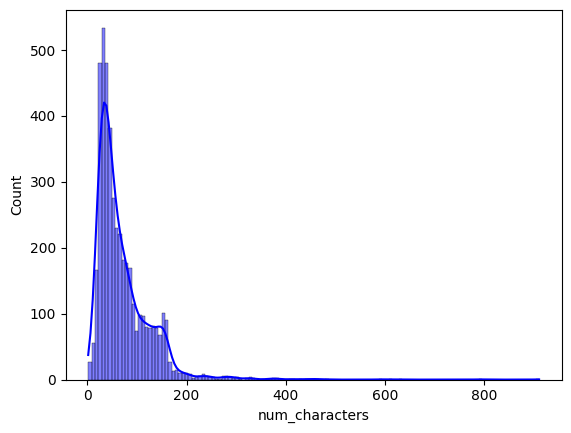

In [30]:
sns.histplot(df[df['target'] == 0]['num_characters'], kde=True, color='blue', label='Not Spam')

<Axes: xlabel='num_characters', ylabel='Count'>

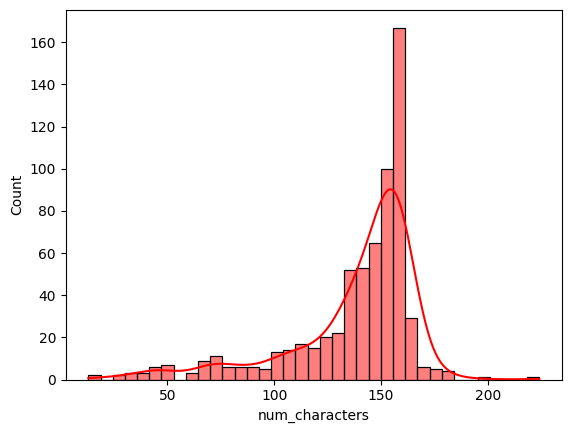

In [31]:
sns.histplot(df[df['target'] == 1]['num_characters'], kde=True, color='red', label='Spam')

<Axes: xlabel='num_characters', ylabel='Count'>

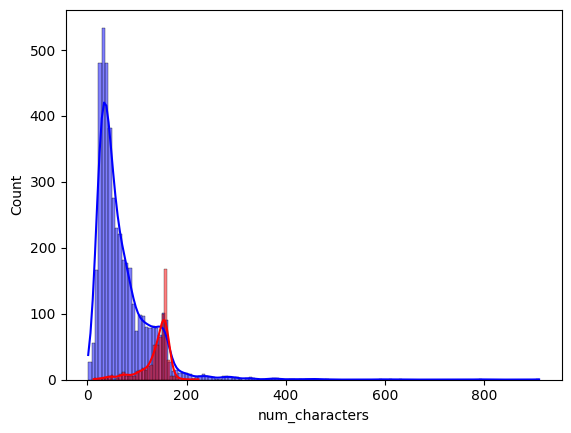

In [32]:
sns.histplot(df[df['target'] == 0]['num_characters'], kde=True, color='blue', label='Not Spam')
sns.histplot(df[df['target'] == 1]['num_characters'], kde=True, color='red', label='Spam')

<Axes: xlabel='num_words', ylabel='Count'>

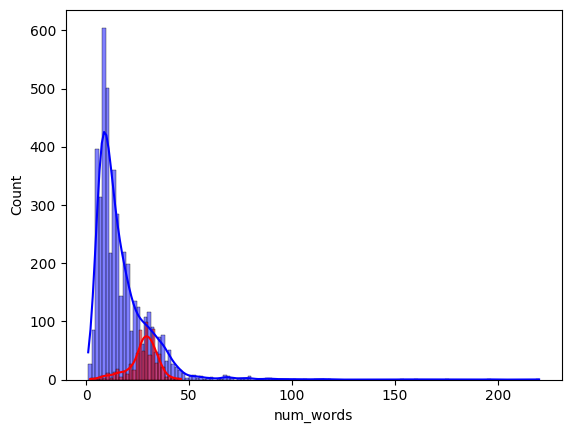

In [33]:
sns.histplot(df[df['target'] == 0]['num_words'], kde=True, color='blue', label='Not Spam')
sns.histplot(df[df['target'] == 1]['num_words'], kde=True, color='red', label='Spam')

<Axes: xlabel='num_sentences', ylabel='Count'>

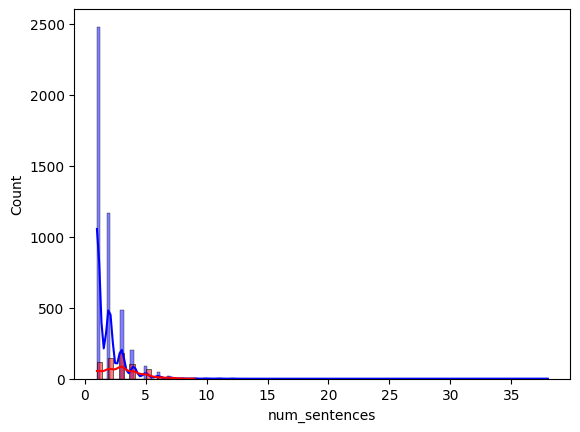

In [34]:
sns.histplot(df[df['target'] == 0]['num_sentences'], kde=True, color='blue', label='Not Spam')
sns.histplot(df[df['target'] == 1]['num_sentences'], kde=True, color='red', label='Spam')

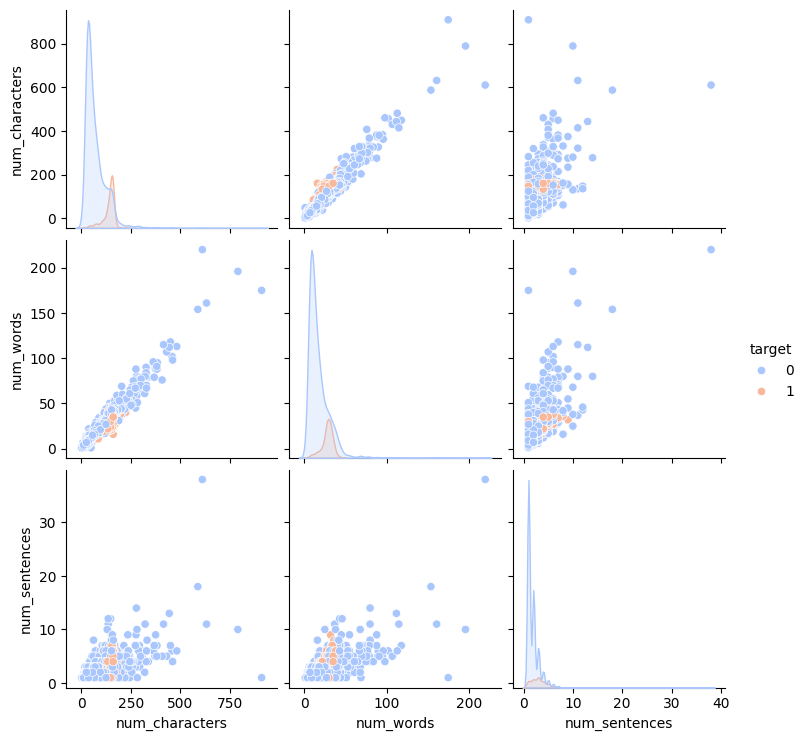

In [35]:
sns.pairplot(df, hue='target', vars=['num_characters', 'num_words', 'num_sentences'], palette='coolwarm')

# Data Preprocessing


#Lower case 
#Tokenization
#Removing special charectors
#Removing stop words and punctuation
#Stemming

In [36]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

def transform_text(text):
    # Convert text to lowercase
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)


    text = y[:]
    y.clear()

    ps = PorterStemmer()
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [37]:
transform_text('Hii how are you doing today Ankit?')

'hii today ankit'

In [38]:
ps = PorterStemmer()
print(ps.stem("Loving Craving"))

loving crav


In [39]:
df['transformed_text'] = df['text'].apply(transform_text)

In [40]:
df.head(5)  

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [41]:
from wordcloud import WordCloud 
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [42]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=' '))

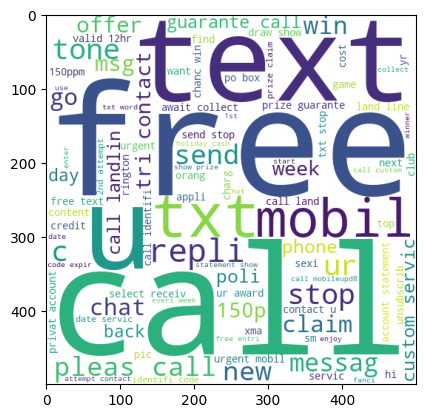

In [43]:
plt.imshow(spam_wc)

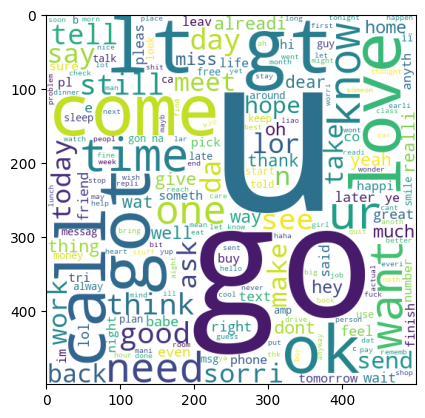

In [44]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=' '))
plt.imshow(ham_wc)

In [45]:
df.head(2)

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni


In [46]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [47]:
len(spam_corpus)

9939

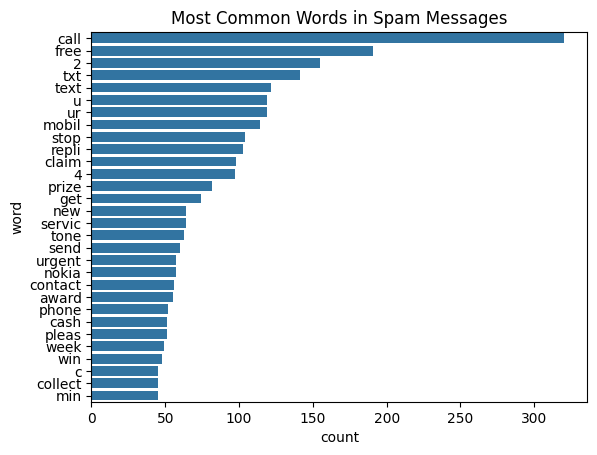

In [48]:
from collections import Counter
spam_words_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(x='count', y='word', data=spam_words_df)
plt.xticks(rotation='horizontal')
plt.title('Most Common Words in Spam Messages')
plt.show()

In [49]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)


In [50]:
len(ham_corpus)

35404

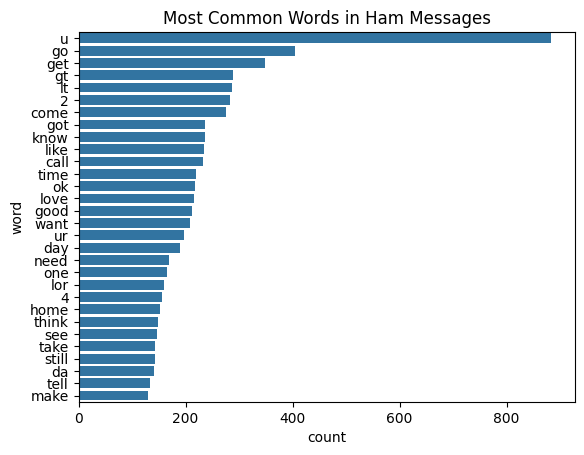

In [51]:
from collections import Counter
ham_words_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(x='count', y='word', data=ham_words_df)
plt.xticks(rotation='horizontal')
plt.title('Most Common Words in Ham Messages')
plt.show()

In [52]:
df.head(2)

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni


# 4. Model Building

#Nife Base

In [53]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [54]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 3000))

In [55]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [56]:
X.shape

(5169, 3000)

In [57]:
y = df['target'].values

In [58]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [59]:
y.shape

(5169,)

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [61]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [62]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [63]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [64]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [65]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


# tfidf --> MNB

In [66]:
# Importing Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [67]:
# Creating Object
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc  = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [68]:
# Dictionary of classifiers
clfs = {
    'SVC'      : svc,
    'KNN'      : knc,
    'NB'       : mnb,
    'DT'       : dtc,
    'LR'       : lrc,
    'RF'       : rfc,
    'AdaBoost' : abc,
    'Bgc'      : bc,
    'ETC'      : etc,
    'GBDT'     : gbdt,
    'xgb'      : xgb
}


In [69]:
# Function to train and evaluate classifier
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision

In [70]:
# Example: testing with one model (SVC)
print(train_classifier(svc, X_train, y_train, X_test, y_test))

(0.9758220502901354, 0.9747899159663865)


In [71]:
# Compare all classifiers
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    print(f"For {name}: Accuracy = {current_accuracy}, Precision = {current_precision}")

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For SVC: Accuracy = 0.9758220502901354, Precision = 0.9747899159663865
For KNN: Accuracy = 0.9052224371373307, Precision = 1.0
For NB: Accuracy = 0.9709864603481625, Precision = 1.0
For DT: Accuracy = 0.9332688588007737, Precision = 0.8415841584158416
For LR: Accuracy = 0.9555125725338491, Precision = 0.96
For RF: Accuracy = 0.9738878143133463, Precision = 0.9826086956521739
For AdaBoost: Accuracy = 0.9216634429400387, Precision = 0.8202247191011236
For Bgc: Accuracy = 0.9584139264990329, Precision = 0.8682170542635659
For ETC: Accuracy = 0.9748549323017408, Precision = 0.9745762711864406
For GBDT: Accuracy = 0.9506769825918762, Precision = 0.9306930693069307
For xgb: Accuracy = 0.9680851063829787, Precision = 0.9487179487179487


In [72]:
# Create performance DataFrame
performance_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
}).sort_values(by='Precision', ascending=False)


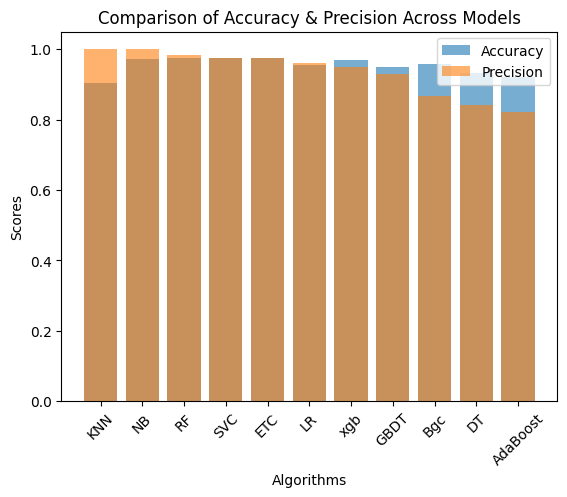

In [73]:
# Accuracy bar
plt.bar(performance_df['Algorithm'], performance_df['Accuracy'], alpha=0.6, label='Accuracy')

# Precision bar
plt.bar(performance_df['Algorithm'], performance_df['Precision'], alpha=0.6, label='Precision')

plt.xlabel("Algorithms")
plt.ylabel("Scores")
plt.title("Comparison of Accuracy & Precision Across Models")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [74]:
# Display performance table
performance_df

,Algorithm,Accuracy,Precision
1,KNN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.973888,0.982609
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.955513,0.960000
10,xgb,0.968085,0.948718
9,GBDT,0.950677,0.930693
7,Bgc,0.958414,0.868217
3,DT,0.933269,0.841584


In [75]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))

In [76]:
# pip install numpy pandas matplotlib seaborn scikit-learn nltk wordcloud xgboost